# W11

In [8]:
pip install emcee

Note: you may need to restart the kernel to use updated packages.


In [9]:
pip install corner

  Using cached corner-2.2.3-py3-none-any.whl.metadata (2.2 kB)
Using cached corner-2.2.3-py3-none-any.whl (15 kB)
Note: you may need to restart the kernel to use updated packages.


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner
import random
import scipy.stats as stats

In [11]:
data = np.load('/Users/lorenzaimpicicche/Desktop/astrostatistics_bicocca_2025/solutions/transient.npy')

In [15]:
data

array([[ 0.46954762,  8.83485016,  1.        ],
       [ 1.87898004, 10.90082649,  1.        ],
       [ 2.01075462, 10.46566244,  1.        ],
       [ 2.02183974,  8.46375631,  1.        ],
       [ 3.91877923, 11.48825219,  1.        ],
       [ 6.02254716, 11.89588918,  1.        ],
       [ 6.41474963, 11.17877957,  1.        ],
       [ 7.10360582,  9.82007516,  1.        ],
       [ 8.71292997,  8.92924738,  1.        ],
       [ 9.39405108, 11.05445173,  1.        ],
       [ 9.60984079,  9.59682305,  1.        ],
       [ 9.71012758, 11.22244507,  1.        ],
       [10.20448107, 10.20827498,  1.        ],
       [11.03751412, 10.97663904,  1.        ],
       [11.82744259, 10.3563664 ,  1.        ],
       [11.8727719 , 10.70657317,  1.        ],
       [12.01965612, 10.01050002,  1.        ],
       [12.89262977, 11.78587049,  1.        ],
       [13.17978624, 10.12691209,  1.        ],
       [13.81829513, 10.40198936,  1.        ],
       [14.33532874, 11.8831507 ,  1.   

Text(0, 0.5, 'Flx')

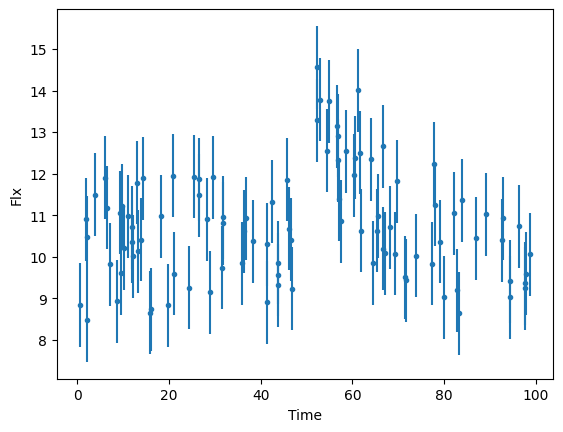

In [29]:
t0, flux0, err0=data[:, 0], data[:, 1], data[:, 2]
plt.errorbar(t0, flux0, yerr=err0, fmt='.')
plt.xlabel("Time")
plt.ylabel("Flx")

In [30]:
def burst_model(t, b, A, t0, alpha):
    y = np.where(t<t0, b, b + A * np.exp(-alpha*(t-t0)))
    return y

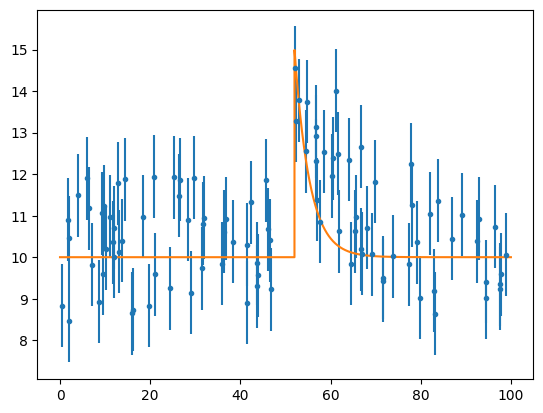

In [45]:
x=np.linspace(0,100,10000)
y=burst_model(x,10,5,52,0.3)
plt.errorbar(t0, flux0, yerr=err0, fmt='.')
plt.plot(x, y)

In [48]:
def log_likelihood(b, A, t_burst, ln_alpha):
    alpha = np.exp(ln_alpha)
    model = burst_model(t0, b, A, t_burst, alpha)
    return -0.5 * np.sum(((flux0 - model) / err0) ** 2 + np.log(2 * np.pi * err0**2))

In [49]:
def log_prior(b, A, t_burst, ln_alpha):
    if 0 < b < 50 and 0 < A < 50 and 0 < t_burst < 100 and -5 < ln_alpha < 5:
        return 0.0
    return -np.inf

In [50]:
def log_posterior(params):
    b, A, t_burst, ln_alpha = params
    lp = log_prior(b, A, t_burst, ln_alpha)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(b, A, t_burst, ln_alpha)

In [51]:
ndim = 4 # N param model
nwalkers = 50
nsteps = 10000
initial = [25, 25, 50, 0]
p0 = initial + 1e-4 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior)
sampler.run_mcmc(p0, nsteps, progress=True)

  0%|                                                 | 0/10000 [00:00<?, ?it/s]/var/folders/cb/61f4dr4x06v372b0m7m0wmv80000gn/T/ipykernel_5064/1960250997.py:2: RuntimeWarning: overflow encountered in exp
  y = np.where(t<t0, b, b + A * np.exp(-alpha*(t-t0)))
/var/folders/cb/61f4dr4x06v372b0m7m0wmv80000gn/T/ipykernel_5064/1960250997.py:2: RuntimeWarning: overflow encountered in multiply
  y = np.where(t<t0, b, b + A * np.exp(-alpha*(t-t0)))
100%|███████████████████████████████████| 10000/10000 [00:06<00:00, 1446.18it/s]


State([[10.34593489  7.38019004 47.867266   -1.85642278]
 [10.27020104  4.98481632 47.81571183 -2.33522275]
 [10.32773646  9.88064434 47.39168929 -1.70349753]
 [10.20682175  2.44582908 51.73424194 -2.55996678]
 [10.32768149  4.22615053 50.7392272  -1.90609666]
 [10.22511753  8.63344801 48.92649701 -1.74526547]
 [10.36242085  7.59330667 48.17437812 -1.83406906]
 [10.18560976  6.12662627 46.93958305 -2.34351322]
 [10.39557497  4.78632767 50.36778584 -1.745841  ]
 [10.6856305  43.62589268 25.44022178  3.81576694]
 [10.32245955  6.12561471 49.53530282 -1.76663878]
 [10.43091396  6.24002555 48.52475003 -2.12179863]
 [10.3984094   5.39900358 49.67712755 -1.99961035]
 [10.15837475  6.55095141 49.17396264 -1.98719279]
 [10.22872216  4.87318124 50.87462519 -1.93611313]
 [10.34456647  4.16462879 50.89856582 -1.99444694]
 [10.09606605  5.65527279 50.53707678 -1.88965641]
 [10.29333802  6.0408935  48.55892463 -2.26698463]
 [10.31286073  2.80142691 50.49780205 -2.46444788]
 [10.10707904  5.81129445

In [67]:
#burn in, thinning
tau = sampler.get_autocorr_time()
burn = int(2 * np.max(tau))
thin = int(np.max(tau))
samples = sampler.get_chain(discard=burn, thin=thin, flat=True)

print(f"Autocorrelation time: {tau}")
print(f"Samples after thinning: {samples.shape}")

Autocorrelation time: [ 74.44097093 109.0656135  127.76464355 171.79126446]
Samples after thinning: (2800, 4)


In [68]:
samples.shape

(2800, 4)

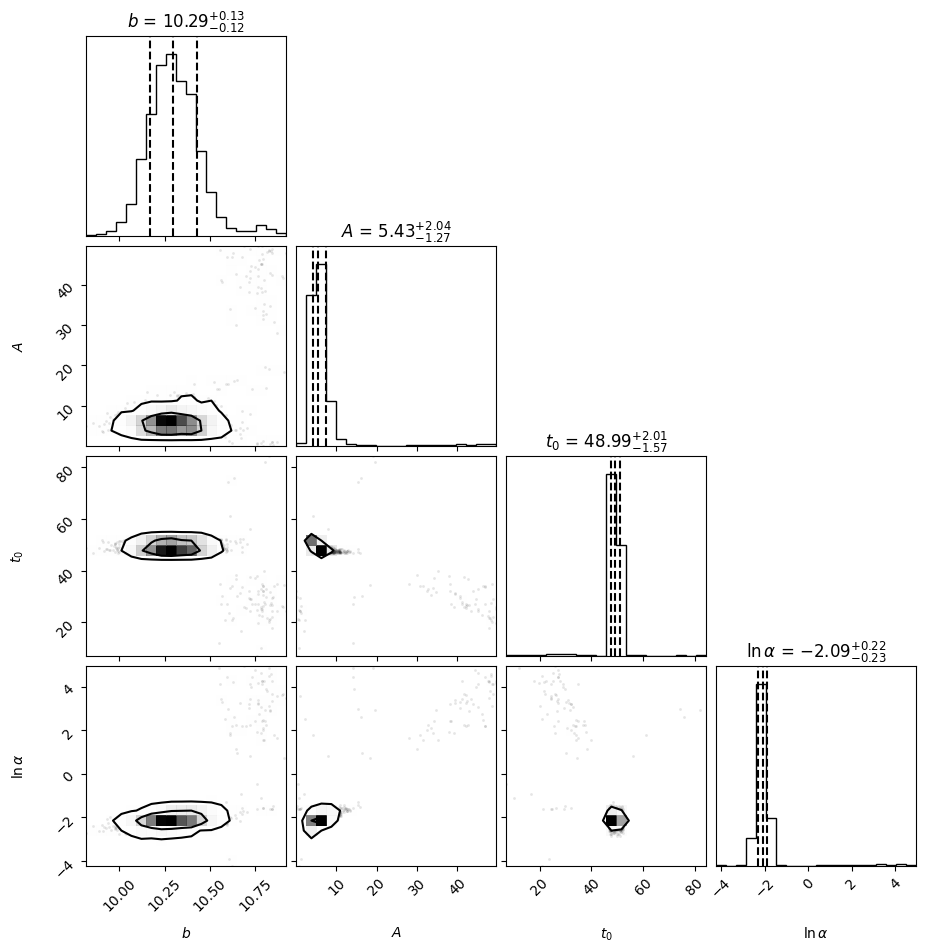

In [69]:
labels = [r"$b$", r"$A$", r"$t_0$", r"$\ln\alpha$"]
corner.corner(samples, labels=labels, quantiles=[0.16, 0.5, 0.84],
              show_titles=True, title_fmt=".2f", title_kwargs={"fontsize": 12},
              levels=[0.68, 0.95])
plt.show()

/var/folders/cb/61f4dr4x06v372b0m7m0wmv80000gn/T/ipykernel_5064/1960250997.py:2: RuntimeWarning: overflow encountered in exp
  y = np.where(t<t0, b, b + A * np.exp(-alpha*(t-t0)))


Text(0, 0.5, 'Flux')

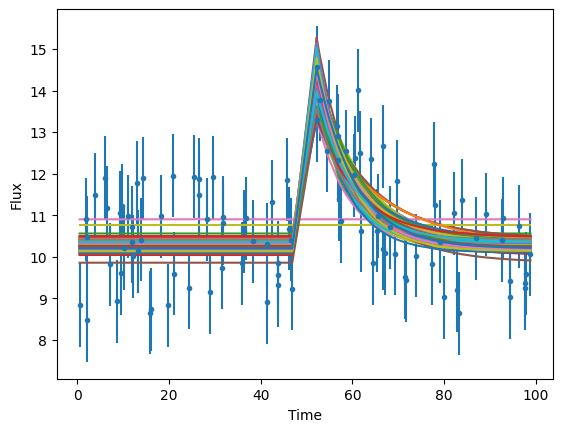

In [71]:
plt.errorbar(t0, flux0, yerr=err0, fmt=".")

inds = np.random.choice(samples.shape[0], 100, replace=False)
for i in inds:
    b, A, t_burst, ln_alpha = samples[i]
    alpha = np.exp(ln_alpha)
    model_flux = burst_model(t0, b, A, t_burst, alpha)
    plt.plot(t0, model_flux)
plt.xlabel("Time")
plt.ylabel("Flux")

In [73]:
def summary(vals, label, transform=lambda x: x):
    vals = transform(vals)
    med = np.median(vals)
    lo = np.percentile(vals, 5)
    hi = np.percentile(vals, 95)
    print(f"{label} = {med:.2f} (+{hi - med:.2f}/-{med - lo:.2f})")

In [74]:
summary(samples_2d[:, 0], "b")
summary(samples_2d[:, 1], "A")
summary(samples_2d[:, 2], "t_0")
summary(samples_2d[:, 3], "ln(alpha)")

b = 10.30 (+0.29/-0.21)
A = 5.46 (+4.45/-1.93)
t_0 = 48.98 (+2.82/-2.06)
ln(alpha) = -2.09 (+0.51/-0.37)
